# Project data exploration - looking at relplot and scatter plots
Using a dataset that your group is consider using for the term project, let's do some data exploring of the different features in your dataset and their relationships

Group name: Team6

Created by Brian Luong (016187743), Andrew Chen (018035679), Joshua Layokun (016336281)

Last updated: 3/5/2026

This dataset contains the data of over fifteen thousand game with their user and critic scores, global and regional sales, publisher and developer, etc.

Import your data. If you want to mount your Google drive you can use `from google.colab import drive` and `drive.mount('/content/drive')`

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

games = pd.read_csv("/content/drive/MyDrive/CS133/Video_Games_Sales_as_at_22_Dec_2016.csv")
games.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


### Q1: Show the number of missing data in each column of the dataframe

In [4]:
games.isnull().sum()

,0
Name,2
Platform,0
Year_of_Release,269
Genre,2
Publisher,54
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


### Q2: Show the data type for each column of the dataframe

In [6]:
games.dtypes

,0
Name,object
Platform,object
Year_of_Release,float64
Genre,object
Publisher,object
NA_Sales,float64
EU_Sales,float64
JP_Sales,float64
Other_Sales,float64
Global_Sales,float64


### Q3: Create a pair plot to show pairwise relationship in this dataset.
Draw the pairwise polynomial regression lines in a different color than the data points. Use a light color for the data points to deemphasizing the points to make the regression line stand out. Include a meaningful title to the plot.

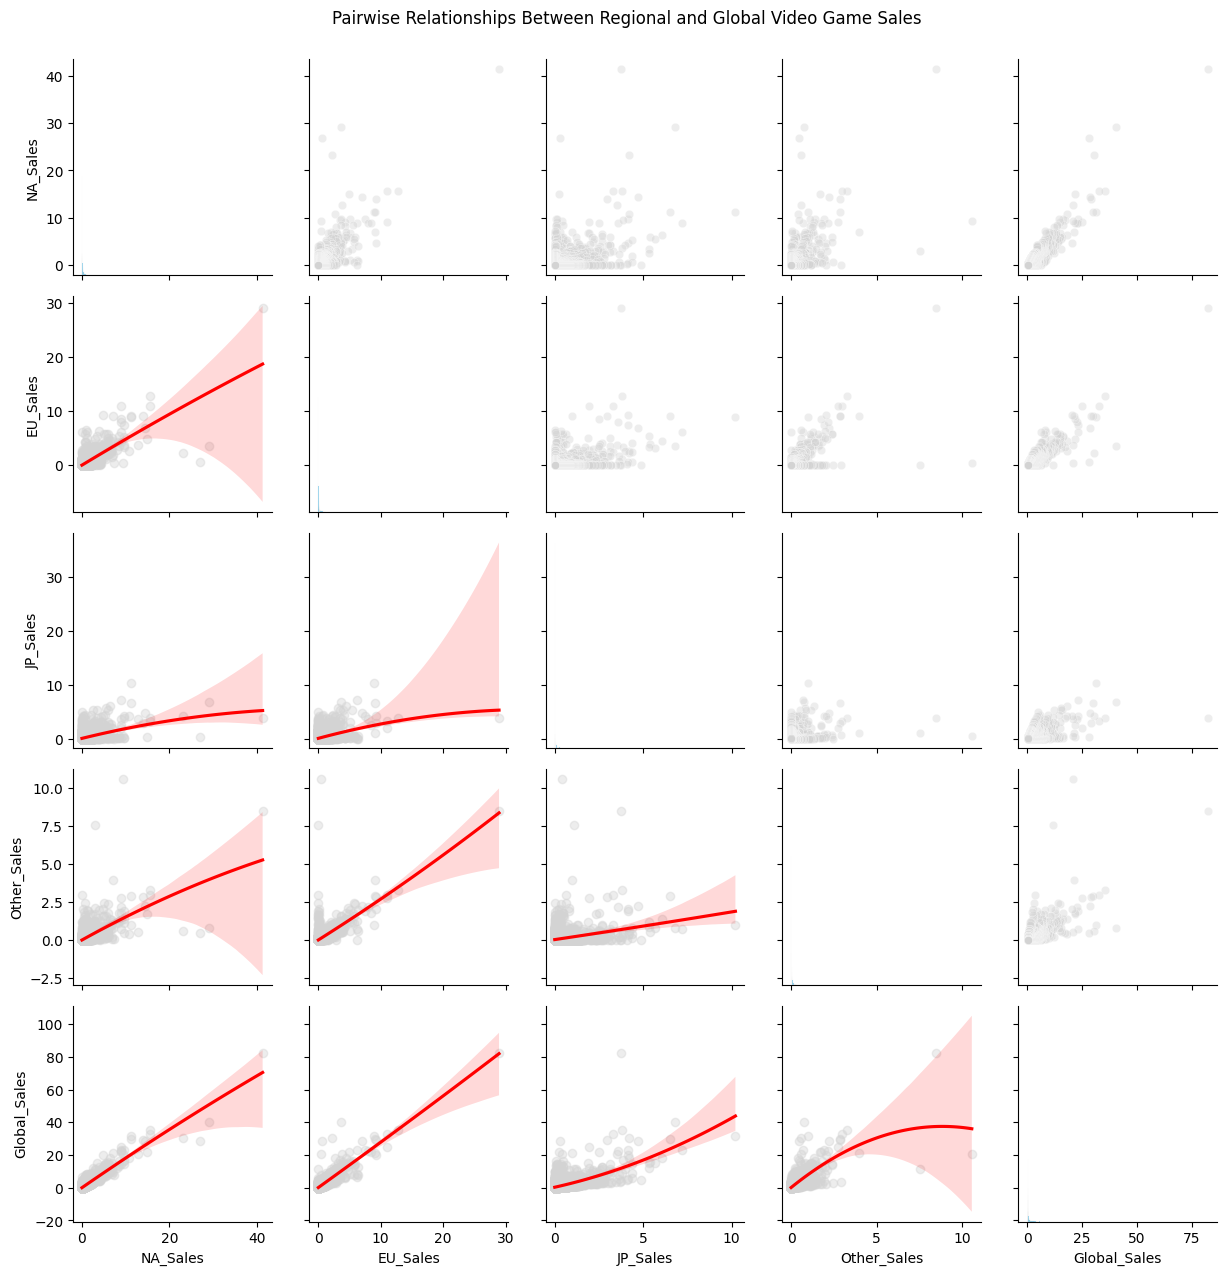

In [7]:
sales_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales", "Global_Sales"]
sales = games[sales_cols].dropna()

g = sns.PairGrid(sales)

g.map_upper(
    sns.scatterplot,
    color="lightgray",
    alpha=0.4
)

g.map_lower(
    sns.regplot,
    order=2,
    scatter_kws={"color": "lightgray", "alpha":0.4},
    line_kws={"color": "red"}
)

g.map_diag(sns.histplot, color="skyblue")

plt.suptitle("Pairwise Relationships Between Regional and Global Video Game Sales", y=1.02)
plt.show()

### Q4: Plot a regression line and confidence interval
Select two of the features from your dataset and create a lmplot that shows the linear regression between them. Filter your data as you see fit. Include a meaningful title for the plot.

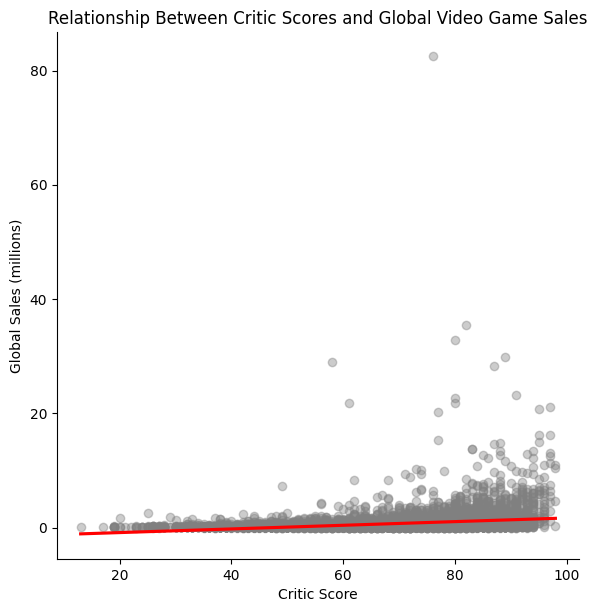

In [8]:
filtered = games[["Critic_Score", "Global_Sales"]].dropna()

sns.lmplot(
    data=filtered,
    x="Critic_Score",
    y="Global_Sales",
    height=6,
    scatter_kws={"alpha":0.4, "color":"gray"},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Critic Scores and Global Video Game Sales")
plt.xlabel("Critic Score")
plt.ylabel("Global Sales (millions)")
plt.show()

### Q5. Create a relplot that shows multiple features in a single plot.
Select two features from your dataset and plot a scatter plot. Select two additional features you want to highlight in your data points using `hue` and `size`. Include a meaningful title to the plot.

/tmp/ipykernel_162/204572446.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  vgs_crit["User_Score"] = pd.to_numeric(vgs_crit["User_Score"], errors="coerce")


Text(0.5, 28.999999999999986, 'Critic Scores')

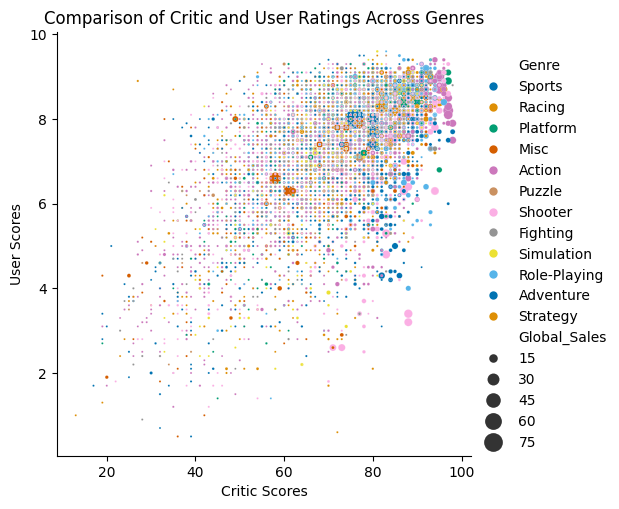

In [9]:
vgs_crit = games.dropna(subset="Critic_Score")
vgs_crit["User_Score"] = pd.to_numeric(vgs_crit["User_Score"], errors="coerce")
vgs_crit = vgs_crit.dropna(subset="User_Score")

sns.relplot(data=vgs_crit, x="Critic_Score", y="User_Score", size="Global_Sales", hue="Genre", sizes=(2, 200), palette="colorblind")

plt.title("Comparison of Critic and User Ratings Across Genres")
plt.ylabel("User Scores")
plt.xlabel("Critic Scores")

### Q6: Create a plot with small multiples plots
Select two features from your dataset and show the relationship between the features with an additional feature as the single category. Organize the multiple plots to have 3 plots per row. Set the `height` of the plot to 5 and the size the of data point to 20. Include a meaningful title in the plot.

Text(0.5, 1, 'Relationship Between Critic Score and User Score by Genre')

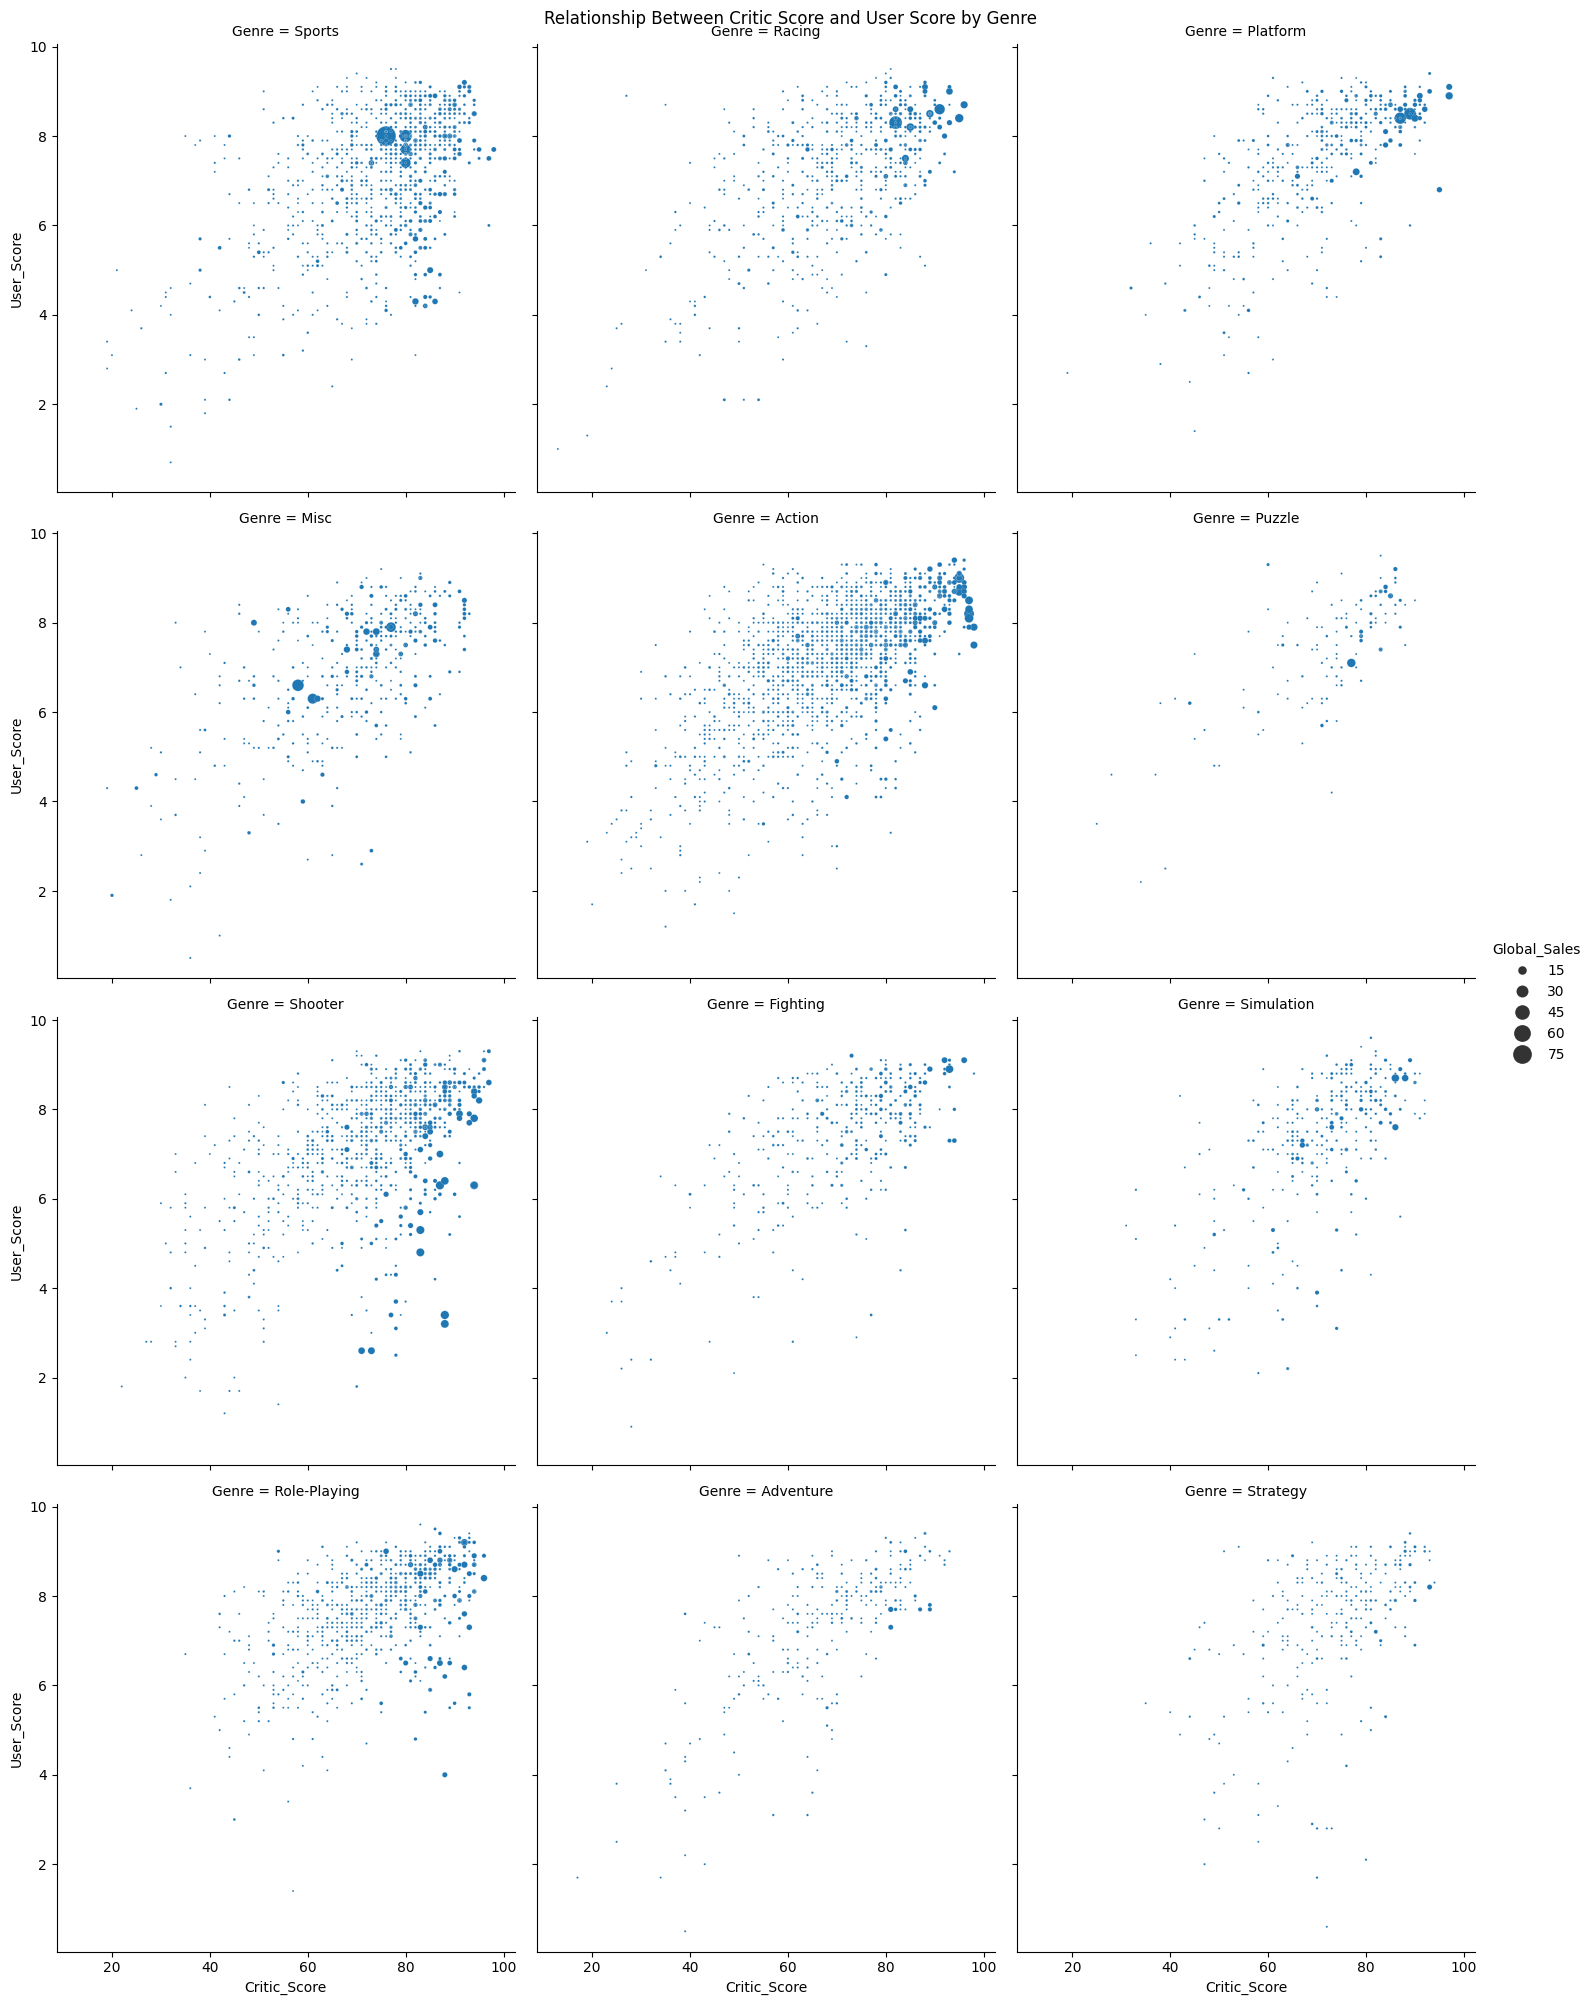

In [10]:
a = sns.relplot(data=vgs_crit, x="Critic_Score", y="User_Score", col="Genre", size="Global_Sales", sizes=(2, 200), col_wrap=3, height=5)
a.fig.suptitle("Relationship Between Critic Score and User Score by Genre", y=1)